[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wjd123p/IT326-Project/blob/main/Phase2.ipynb)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("Raw_dataset.csv")
df_raw = df.copy()

df_raw.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


# Phase 2: Data Summarization and Preprocessing

## Q1 - Data Analysis

### Raw Dataset Snapshot

### 1. Statistical Summary

In [ ]:
# Statistical Summary

df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


The statistical summary provides an overview of the numerical attributes in the dataset, including their mean, standard deviation, minimum, and maximum values. The results show that the average study time is 3.57 hours, the average attendance is 85.09%, the average sleep duration is 6.80 hours, the average previous grade is 69.74, and the average final exam score is 83.54. This helps in understanding the central tendency and spread of the numerical attributes.

### 2. Five Number Summary

In [ ]:
df.describe().loc[['min', '25%', '50%', '75%', 'max']]

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
min,1.00,0.5,54.8,3.2,31.3,46.800
25%,250.75,2.6,78.8,5.9,61.0,76.075
50%,500.50,3.6,85.2,6.8,69.6,83.800
75%,750.25,4.5,91.9,7.6,78.4,91.525
max,1000.00,8.1,100.0,10.0,100.0,100.000


### 3. Histogram

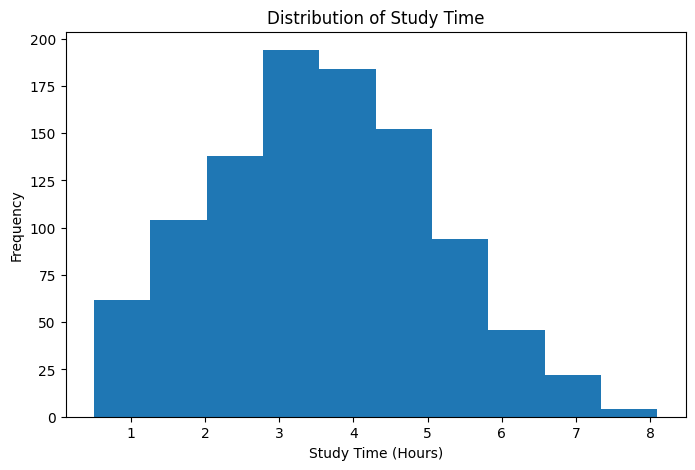

In [ ]:
# Histogram
plt.figure(figsize=(8,5))
plt.hist(df['study_time_hours'], bins=10)
plt.xlabel('Study Time (Hours)')
plt.ylabel('Frequency')
plt.title('Distribution of Study Time')
plt.show()

The histogram shows the distribution of students' study time. Most students study between 2 and 5 hours, with the highest frequency around 3 to 4 hours. The frequency decreases as study time increases. This helps understand the distribution of the study time variable and identify the most common values.

## Q2 - Data Preprocessing
### 1. Normalization

In [ ]:
# Min-Max Normalization

numeric_columns = [
    'study_time_hours',
    'attendance_percent',
    'sleep_hours',
    'previous_grade',
    'final_exam_score'
]

df_normalized = df.copy()

for col in numeric_columns:
    df_normalized[col] = (
        (df_normalized[col] - df_normalized[col].min()) /
        (df_normalized[col].max() - df_normalized[col].min())
    )

df_normalized.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,0.460526,0.955752,0.485294,Bachelors,Yes,Yes,No,0.663755,1.000000,A
1,2,Female,0.763158,1.000000,0.367647,High School,Yes,Yes,Yes,0.643377,1.000000,A
2,3,Male,0.578947,0.674779,0.691176,Bachelors,Yes,No,Yes,0.832606,0.949248,A
3,4,Male,0.276316,0.502212,0.705882,NaN,Yes,Yes,No,0.783115,0.695489,B
4,5,Male,0.223684,0.769912,0.205882,Bachelors,Yes,No,Yes,0.443959,0.404135,D


Normalization was applied to the numerical attributes using Min-Max Normalization. The values were transformed to a common range between 0 and 1. This gives the numerical attributes a similar scale and prevents attributes with larger ranges from having a greater effect on the analysis.